# NBA Scrapper using py_ball

In [1]:
%pip install nba_api pandas

  Using cached nba_api-1.9.0-py3-none-any.whl (284 kB)
  Using cached requests-2.32.3-py3-none-any.whl (64 kB)
  Using cached numpy-2.2.6-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (16.8 MB)
  Using cached pandas-2.2.3-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (13.1 MB)
  Using cached tzdata-2025.2-py2.py3-none-any.whl (347 kB)
  Attempting uninstall: requests
    Found existing installation: requests 2.28.1
    Uninstalling requests-2.28.1:
      Successfully uninstalled requests-2.28.1
  Attempting uninstall: numpy
    Found existing installation: numpy 1.23.4
    Uninstalling numpy-1.23.4:
      Successfully uninstalled numpy-1.23.4
  Attempting uninstall: pandas
    Found existing installation: pandas 1.5.1
    Uninstalling pandas-1.5.1:
      Successfully uninstalled pandas-1.5.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflic

In [2]:
%pip install numpy==1.23.5 --force-reinstall
%pip install matplotlib --force-reinstall


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 6.1 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: numpy
    Found existing installation: numpy 2.2.6
    Uninstalling numpy-2.2.6:
      Successfully uninstalled numpy-2.2.6
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
nba-api 1.9.0 requires numpy>=1.26.0; python_version < "3.13", but you have numpy 1.23.5 which is incompatible.
Note: you may need to restart the kernel to use updated packages.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 5.3 MB/s eta 0:00:0000:0100:01
  Using cached numpy-2.2.6-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (16.8 MB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 7.3 MB/s eta 0:00:00:00:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.1/111.1 kB 1.1 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

In [3]:
from nba_api.stats.static import teams
import pandas as pd
from datetime import datetime, timedelta
from src.config import *
from src.utils import *
import time

#today formated as YYYY-MM-DD
today = datetime.today().strftime('%Y-%m-%d')
today_precise = datetime.today().strftime('%Y-%m-%d_%H-%M-%S')


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/opt/conda/lib/python3.10/runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/opt/conda/lib/python3.10/runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "/opt/conda/lib/python3.10/site-packages/ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "/opt/conda/lib/python3.10/site-packages/traitlets/config/application.py", line 982, in launch_instance
    app.start()
  File "/opt/conda/lib/python3.10/site-packages/ipykernel/

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/opt/conda/lib/python3.10/runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/opt/conda/lib/python3.10/runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "/opt/conda/lib/python3.10/site-packages/ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "/opt/conda/lib/python3.10/site-packages/traitlets/config/application.py", line 982, in launch_instance
    app.start()
  File "/opt/conda/lib/python3.10/site-packages/ipykernel/

AttributeError: _ARRAY_API not found

## Fetch Players data

In [ ]:
import pandas as pd
from nba_api.stats.static import players
import os


#load all boxscores files from the lastest file

boxscores_file = get_latest_file(DATA_LAST_BOXSCORES_BATCHES_MERGED_DIR)

boxscores_df = pd.read_csv(boxscores_file, low_memory=False, dtype={'GAME_ID': str})

# 1. Get all player IDs seen in the boxscores
player_ids_seen = set(boxscores_df['PLAYER_ID'].dropna().astype(int).unique())

# 2. Get all NBA players (historical and active)
nba_players = players.get_players()
nba_players_df = pd.DataFrame(nba_players)
nba_players_df['id'] = nba_players_df['id'].astype(int)

# 3. Add flag: has this player been seen in your dataset?
nba_players_df['in_boxscore'] = nba_players_df['id'].isin(player_ids_seen)

# (Optionnel) Add "nb_appearances" (number of games in boxscores for each player)
counts = boxscores_df['PLAYER_ID'].value_counts().astype(int)
nba_players_df['nb_appearances'] = nba_players_df['id'].map(counts).fillna(0).astype(int)

# 4. Save the complete master file
#nba_players_df.to_csv(os.path.join(DATA_PLAYERS_DIR, 'players_master.csv'), index=False)

save_dataframe_to_csv(nba_players_df, DATA_PLAYERS_DIR, prefix='players_master_', suffix=today_precise)

print("✅ Players master file saved with historicals and seen flags!")


✅ Players master file saved with historicals and seen flags!


## Quick visualization

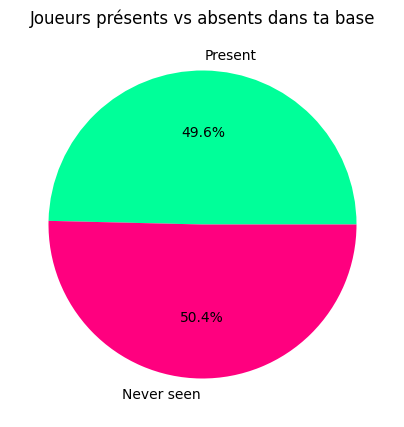

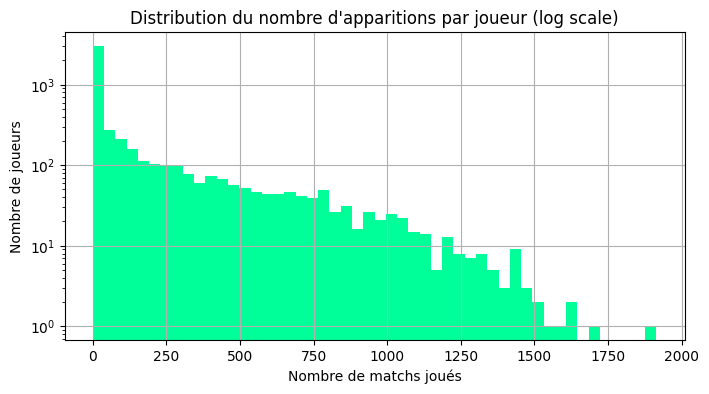

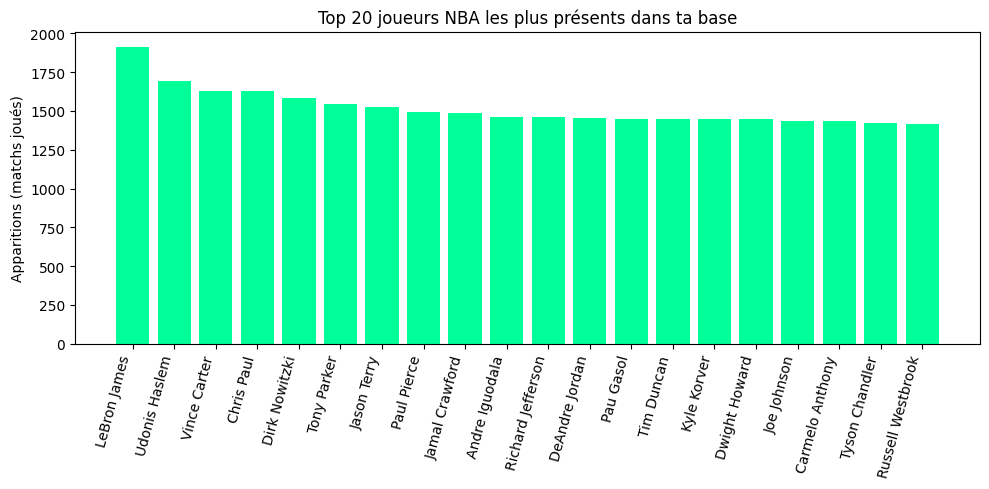

2531 joueurs historiques jamais vus dans tes boxscores !


,id,full_name,first_name,last_name,is_active,in_boxscore,nb_appearances
0,76001,Alaa Abdelnaby,Alaa,Abdelnaby,False,False,0
1359,76709,Rolando Ferreira,Rolando,Ferreira,False,False,0
3969,78097,Charlie Scott,Charlie,Scott,False,False,0
468,76233,Bill Bradley,Bill,Bradley,False,False,0
2332,77194,Robin Jones,Robin,Jones,False,False,0
3405,1077,Ray Owes,Ray,Owes,False,False,0
2071,77082,Rod Hundley,Rod,Hundley,False,False,0
858,76428,Gene Conley,Gene,Conley,False,False,0
708,1131,Jimmy Carruth,Jimmy,Carruth,False,False,0
2975,77565,Cozell McQueen,Cozell,McQueen,False,False,0


In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# Charge ton master file
players_master = pd.read_csv(get_latest_file(DATA_PLAYERS_DIR))

# 1. Combien de joueurs présents vs absents dans tes datas
present = players_master['in_boxscore'].sum()
total = len(players_master)
absents = total - present

plt.figure(figsize=(5, 5))
plt.pie([present, absents], labels=['Present', 'Never seen'], autopct='%1.1f%%', colors=['#00FF99', '#FF007F'])
plt.title("Joueurs présents vs absents dans ta base")
plt.show()

# 2. Distribution du nombre d'apparitions (log pour voir les extrêmes)
plt.figure(figsize=(8, 4))
players_master['nb_appearances'].hist(bins=50, log=True, color='#00FF99')
plt.title("Distribution du nombre d'apparitions par joueur (log scale)")
plt.xlabel("Nombre de matchs joués")
plt.ylabel("Nombre de joueurs")
plt.show()

# 3. Top 20 joueurs les plus présents
top20 = players_master.sort_values('nb_appearances', ascending=False).head(20)
plt.figure(figsize=(10, 5))
plt.bar(top20['full_name'], top20['nb_appearances'], color='#00FF99')
plt.title("Top 20 joueurs NBA les plus présents dans ta base")
plt.xticks(rotation=75, ha='right')
plt.ylabel("Apparitions (matchs joués)")
plt.tight_layout()
plt.show()

# 4. Pour le fun : joueurs jamais vus (curiosité)
never_seen = players_master[~players_master['in_boxscore']]
print(f"{len(never_seen)} joueurs historiques jamais vus dans tes boxscores !")
display(never_seen.sample(10))
